# Technical Exercise
## Analysis and comparison of biosignals using different sensors

We have two datasets collected using distinct biomedical devices (`data` folder): `FPdata.xls` and `labchartdata.csv`

### Data Properties:
- `FPdata.xls`:
    - Recorded in a discontinuous manner with nonlinear sampling rate: time stamps correspond to detected start time of a beat;
    - Labeled based on the pressure stage during which the recording was made (Baseline, Stage1, Stage 2). It is not confirmed when the start and end of the FP recording was made relative to pressure chamber stage changes.
- `labchartdata.csv`:
    - Recorded continuously from start to finish with a sampling rate of 1000 Hz.
- Both:
    - Recordings do not necessarily have the same start time;
    - Common metric between 2 datasets: Heart rate (HR).

**Metrics to compare: Cardiac output (CO; `labchartdata.csv`) and Velocity time integral (VTI; `FPdata.xls`).**

In [11]:
import pandas as pd, numpy as np, os, sys
from scipy.interpolate import interp1d
from scipy import signal, stats
import matplotlib.pyplot as plt, seaborn as sns

sys.path.append(os.path.abspath(os.path.join("..")))
from src.loaders import load_data
from src.plotters import plot_HR_by_stage, plot_co_vti_overlay, bland_altman_plot, regression_plot
from src.processors import get_running_time, get_stage_offset
from src.analyzers import build_analysis_df, _stage_metrics

fp_data, labchart_data = load_data('../data/')

## Exploratory Data Analysis / Pre-Processing
We are told that the `FPdata.xls` was recorded in a discontinuous manner with a non-linear sampling rate, and was labeled by stage. We can visualize this with our helper function (`src/plotters.py`). 

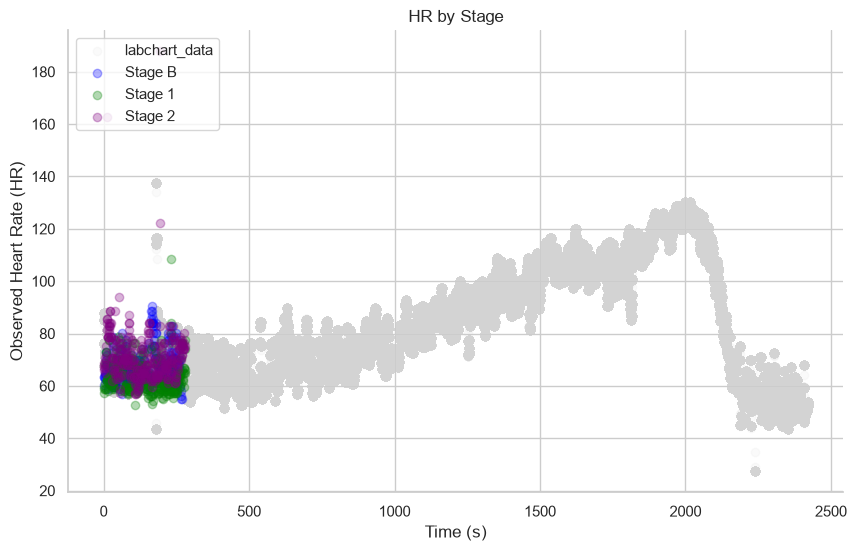

In [12]:
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Time (s)', hr_col='HR')  

It's clear that we need to fix the timeline for the measurements, as the clock restarts at each stage. It is not clear when the start/end of the recording happened relative to the stage changes, but as a first pass we can concatenate the three stages into one running timeline by offsetting each stage's time by the end of the previous one. 

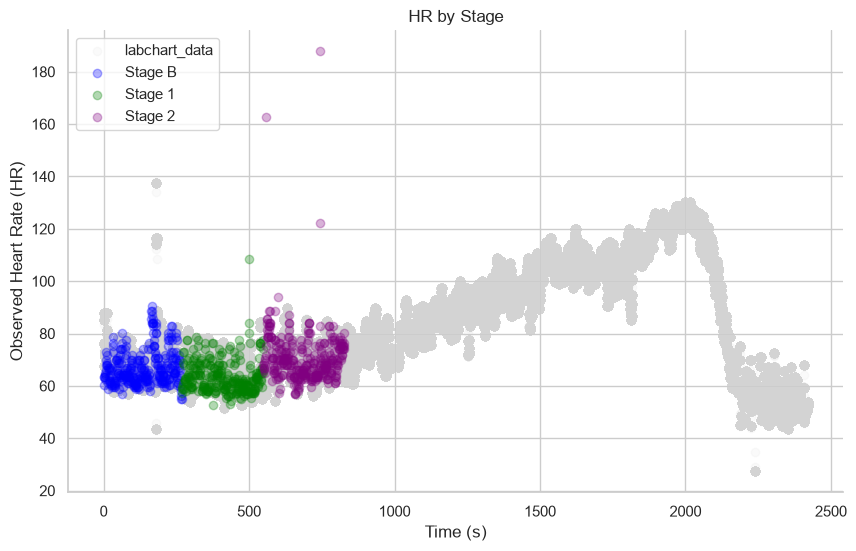

In [13]:
get_running_time(fp_data)
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR')

# sanity check
labchart_data.sort_values('TimeSec', inplace=True, ascending=True)
fp_data.sort_values('Corrected Time (s)', inplace=True, ascending=True)

Okay, this looks a little more like it! We still need to account for some offset between stages, but at least we have a continuous timeline. We also observe some (what look like) erroneous readings; we can consider outlier filtration on both datasets as a future step for tigher alignment and/or improved metric quantification/comparison. 

For now, we'll focus on determinging the stage-specific offsets. To do this, we will use cross-correlation, which is a technique used to measure the similarity of two signals by sliding one relative to the other. This can be visualized below (*[visual credit](https://medium.com/data-science/four-ways-to-quantify-synchrony-between-time-series-data-b99136c4a9c9)*).

How it works:

1. **Sliding Match:** A small template or signal moves step-by-step across another target signal or image.
2. **Similarity Score:** At each step, it calculates a value showing how closely the two shapes match.
3. **Peak Detection:** The highest peak in the output graph shows the exact point of best alignment or time delay (lag).

![Cross Correlation Visualized.](../data/assets/crosscorr.gif)

There is still the matter of non-linear sampling rates for the fp_data and overall differences in sampling frequency between fp_data and labchart_data. To handle this, we will resample both datasets to a consistent, shared frequency, with a preference for downsampling labchart_data versus upsampling fp_data (minimize artificial/interpolated data and lower computational cost).

Once both datasets are resampled, we will perform cross-correlation using the heart rate (HR) signal to determine the stage-specific offsets (`src/processors.py`).

In [14]:
stages = fp_data['Stage'].unique()
time_offsets = {stage: get_stage_offset(stage, fp_data, labchart_data) for stage in stages}

Stage: B
Stage window: 0.528 s to 267.903 s
Estimated sampling frequencies -> labchart window: 1000.000 Hz, fp stage B: 1.085 Hz
Using shared resample frequency: 1.085 Hz
Calculated Time Delay: 18.432 seconds
--------------------------------------------------
Stage: 1
Stage window: 268.616 s to 549.126 s
Estimated sampling frequencies -> labchart window: 1000.000 Hz, fp stage 1: 1.030 Hz
Using shared resample frequency: 1.030 Hz
Calculated Time Delay: 37.859 seconds
--------------------------------------------------
Stage: 2
Stage window: 549.138 s to 827.302 s
Estimated sampling frequencies -> labchart window: 1000.000 Hz, fp stage 2: 1.146 Hz
Using shared resample frequency: 1.146 Hz
Calculated Time Delay: 61.071 seconds
--------------------------------------------------


Now we can apply the stage-specific offsets to synchronize the signals.

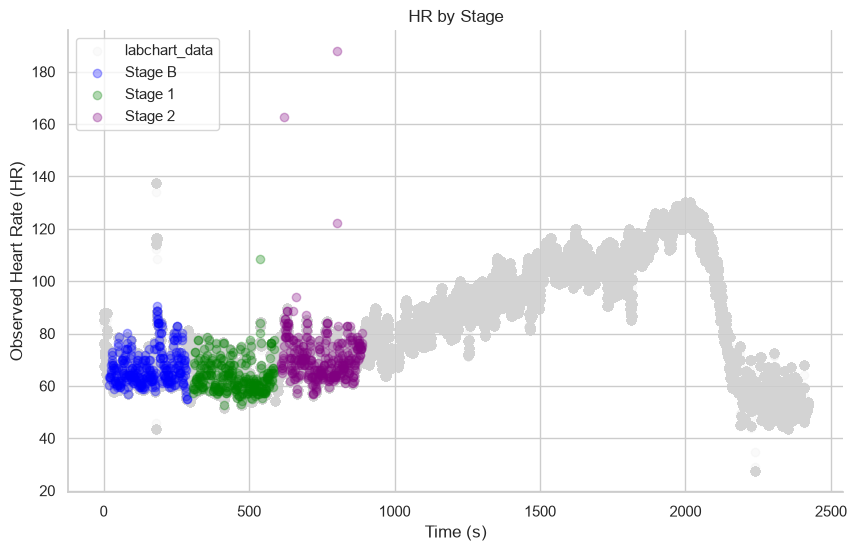

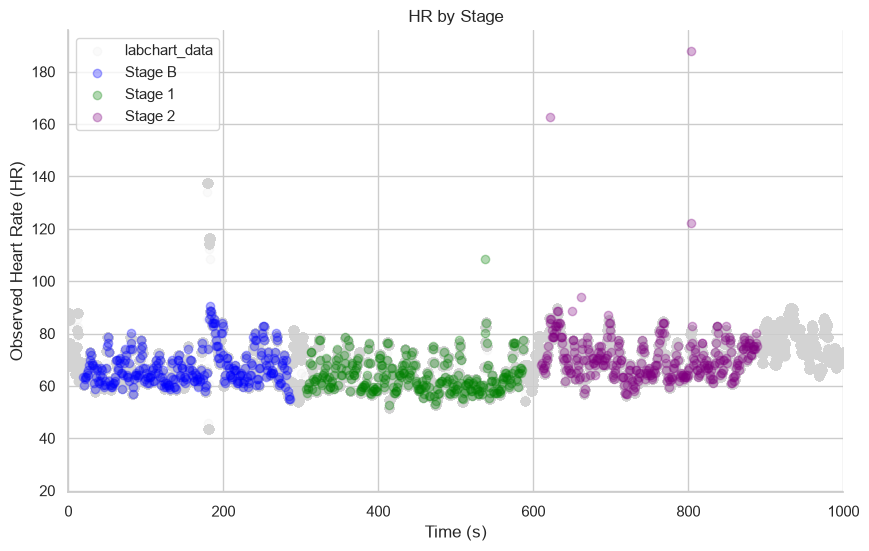

In [15]:
for stage, offset in time_offsets.items():
    mask = fp_data['Stage'] == stage
    fp_data.loc[mask, 'Corrected Time (s)'] = fp_data.loc[mask, 'Corrected Time (s)'] + offset

plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR')
plot_HR_by_stage(fp_data, ref_data=labchart_data, stage_col='Stage', time_col='Corrected Time (s)', hr_col='HR', xlim=(0, 1000))    


That's more like it, woohoo! Now when we're looking at quantitative metrics from these datasets, it's more likely we're comparing apples with apples (so to speak). Now we can approximate the labchart_data at the exact sampling times for fp_data for metric comparison and consolidate relevant information into a final, analysis dataframe.

In [16]:
analysis_df = build_analysis_df(fp_data, labchart_data, remove_invalid=True) # remove_invalid removes any CO or VTI values <=0 b/c not possible physiologically

## Statistical Analysis of CO vs VTI
### Relationship Between CO and VTI

Across all three stages, Nexfin's cardiac output (CO) and Flopatch's velocity time integral (VTI) show a **weak, statistically significant negative correlation** (overall r = -0.26, p < 0.001, n = 880). 

Notably, this relationship **strengthens as LBNP pressure increases**: r = -0.26 at Baseline, -0.31 at Stage 1, and -0.43 at Stage 2. This trend aligns with the physiological premise of the paradigm; as lower body negative pressure progressively reduces central blood volume, the relationship between the two metrics becomes more pronounced.

That said, R² values remain low (0.07–0.18), meaning CO and VTI share only a modest amount of variance even where the correlation is strongest. With sample sizes in the 280-310 range per stage, even weak correlations reach statistical significance easily; so the p-values reflect sample size as much as effect strength. The R² and scatter plots 
give a more honest picture of the practical (rather than statistical) relationship between the two metrics.

In [17]:
stage_order = ['B', '1', '2']  
analysis_df['Stage'] = pd.Categorical(analysis_df['Stage'], categories=stage_order, ordered=True)

stage_summary = analysis_df.groupby('Stage', observed=True).apply(_stage_metrics)

overall_summary = _stage_metrics(analysis_df).to_frame().T
overall_summary.index = ['Overall']

summary_stats = pd.concat([stage_summary, overall_summary], axis=0)
summary_stats

,n,pearson_r,pearson_p,spearman_rho,spearman_p,slope,intercept,R2
B,292.0,-0.256072,9.375534e-06,-0.399669,1.263284e-12,-1.422564,48.673302,0.065573
1,278.0,-0.314667,8.337288e-08,-0.372208,1.457558e-10,-1.952769,52.435474,0.099015
2,310.0,-0.426056,4.213631e-15,-0.439414,4.574001e-16,-2.515064,53.149428,0.181524
Overall,880.0,-0.256455,1.105919e-14,-0.261184,3.433683e-15,-1.484214,48.025730,0.065769


### Time-Aligned CO and VTI Overlay

Plotting CO and VTI together over time (rather than as a static scatter) shows that the two signals **co-fluctuate with a similar cadence**; peaks and dips in CO are often mirrored by peaks and dips in VTI, even though the aggregate correlation is weak. This suggests the two devices may agree more in short-term *dynamics* than in absolute magnitude relationship.

Both metrics stay in a broadly similar range across Baseline, Stage 1, and Stage 2, with no dramatic level-shift between stages, despite the progressive pressure changes in the LBNP protocol.

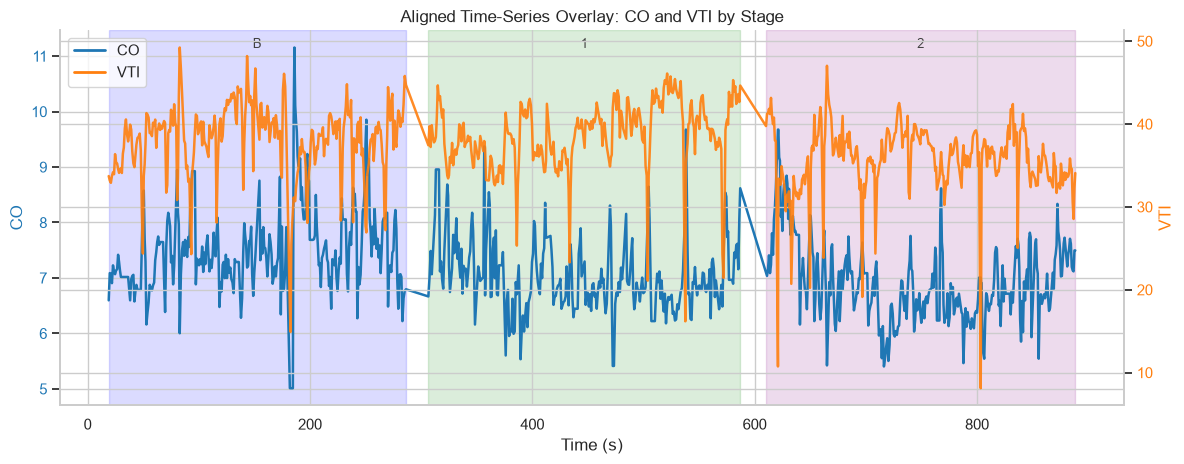

In [18]:
plot_co_vti_overlay(analysis_df, stage_order=['B', '1', '2'])

### CO vs. VTI Regression, by Stage and Overall

Plotting CO against VTI directly confirms the negative relationship seen in the correlation table: as CO increases, VTI tends to decrease, across all three stages. The regression lines and their 95% confidence bands make this trend visually consistent with the earlier statistics: narrower, tighter bands in Stage 1 and Stage 2 compared to Baseline reflect the progressively stronger correlation reported in the table.

The overall regression (pooling all stages) shows the same downward trend, with a wider spread of points reflecting the mix of all three stages combined. As in the correlation table, the tightness of the point cloud around the regression line is fairly loose in all cases (consistent with the low R² values) so while the direction of the 
relationship is clear and consistent, CO alone explains only a modest portion of the variation in VTI.

One visual pattern worth noting: a cluster of low-VTI outliers (roughly VTI < 20) appears across all three stages at a range of CO values, rather than concentrated at any one CO level. These may be worth a quick look: either as a data quality check or as potentially meaningful physiological events (e.g., near-syncope periods).

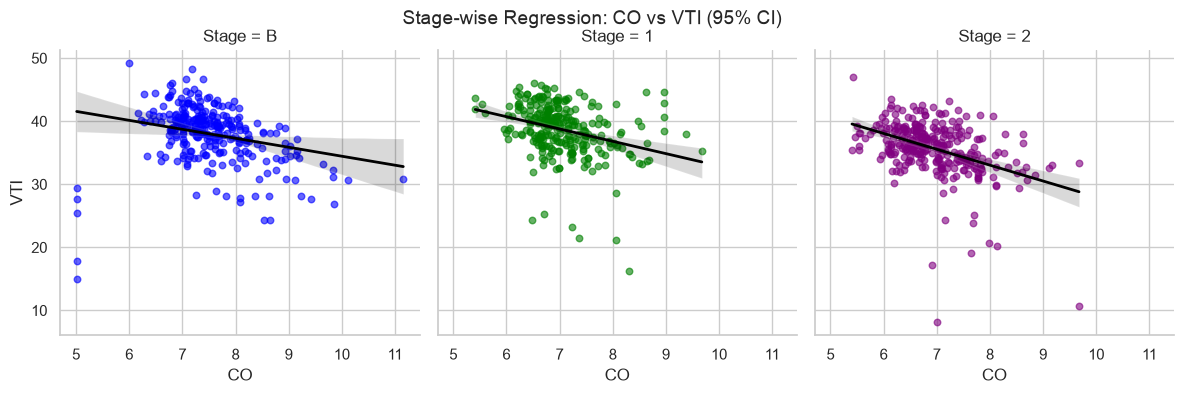

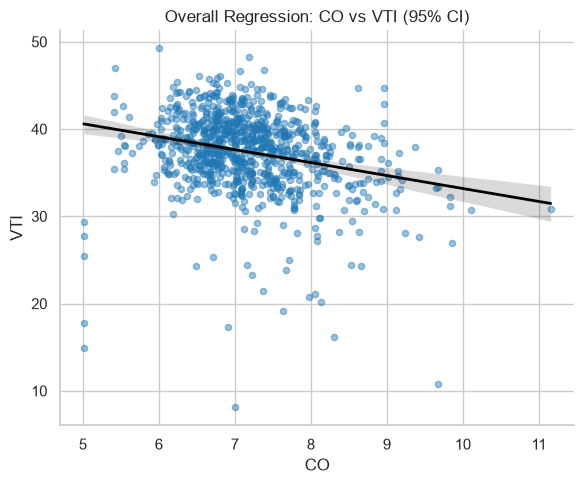

In [19]:
regression_plot(analysis_df)

### Bland-Altman Analysis

Because CO and VTI are measured in different units, both were z-scored before comparison, so the limits of agreement here are expressed in standard-deviation units of disagreement rather than clinical units.

Bias is 0 by construction (a property of z-scoring both variables, not a finding of agreement). The scatter is wide and fairly evenly spread across the range of mean values, with no clear funnel or trend: meaning the level of disagreement between the two normalized metrics doesn't systematically worsen at higher or lower combined values. 

Points from all three stages are fairly intermixed, without an obvious stage-driven pattern in the disagreement.

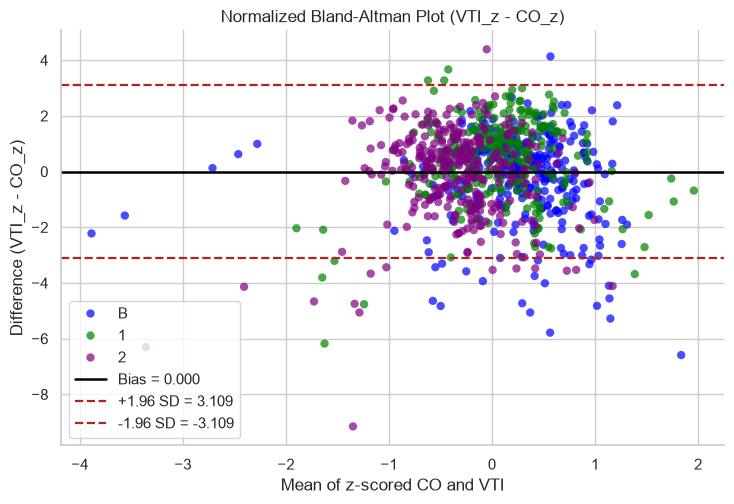

In [20]:
bland_altman_plot(analysis_df)

## Limitations & Next Steps

A few directions I'd explore with additional time:

- **Outlier investigation**: A cluster of low-VTI points (< 20) appears across all three stages and multiple plots (scatter, time-series, Bland-Altman). I did not find an obvious source for these within the scope of this exercise. It may be worth investigating whether they cluster around specific timestamps, coincide with motion artifacts, or represent genuine physiological events (e.g., near-syncope). Depending on the cause, they may warrant exclusion or a separate sensitivity analysis.
- **Lag-adjusted cross-correlation between CO and VTI**: The time-aligned overlay suggests the two signals may track each other more closely in short-term dynamics than the static correlation implies. A follow-up analysis testing whether VTI leads or lags CO by a small, consistent offset (rather than assuming zero-lag correspondence) could clarify whether some of the weak correlation is driven by timing differences between devices rather than a genuinely weak relationship.
- **Stage-boundary validation**: Stage pressure ranges were derived empirically from the synchronized Nexfin data rather than assumed from the written protocol, due to ambiguity in how the stepwise pressure decrease maps onto the three labeled Flopatch stages. It would be worth confirming this approach against the intended protocol design.
- **Larger sample / additional subjects**: This analysis is based on a single session; correlation strength and the stage-wise trend would benefit from 
  validation across multiple subjects to assess generalizability.

Thanks so much for your time and consideration! I had a lot of fun and learned a lot about the data and what you do.